In [1]:
#필요한 모듈 불러오기
import pandas as pd
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AffinityPropagation
from sklearn.manifold import TSNE
import seaborn as sns
import sklearn.metrics as metrics
import numpy as np

/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
#데이터 불러오기
df = pd.read_csv('~/Desktop/gbdata1.csv',encoding='cp949')
df = df.sample(frac=0.1)
features = df.iloc[:,5:]

In [3]:
#preference 결정 및 유사도 전파 함수 실행
ap = AffinityPropagation(preference=-150)

#Labels(분류결과)
Labels = ap.fit_predict(features)

#클러스터 개수 추출
cluster_centers_indices = ap.cluster_centers_indices_
n_clusters_=len(cluster_centers_indices)

#Labels변수 추가
df['ap_pred'] = Labels

/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_affinity_propagation.py:236: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


In [11]:
Labels=np.where(Labels==0, 28, Labels)

In [4]:
#Affinity propagation 성능평가
print('Silhouette Coefficient: %0.3f' % metrics.silhouette_score(features, Labels)) #모든 샘플의 평균 실루엣 계수를 계산합니다.

Silhouette Coefficient: 0.191


/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:795: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:805: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6555 samples in 0.004s...
[t-SNE] Computed neighbors for 6555 samples in 0.196s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6555
[t-SNE] Computed conditional probabilities for sample 2000 / 6555
[t-SNE] Computed conditional probabilities for sample 3000 / 6555
[t-SNE] Computed conditional probabilities for sample 4000 / 6555
[t-SNE] Computed conditional probabilities for sample 5000 / 6555
[t-SNE] Computed conditional probabilities for sample 6000 / 6555
[t-SNE] Computed conditional probabilities for sample 6555 / 6555
[t-SNE] Mean sigma: 0.293273
[t-SNE] Computed conditional probabilities in 0.107s
[t-SNE] Iteration 50: error = 90.2892227, gradient norm = 0.0294406 (50 iterations in 0.805s)
[t-SNE] Iteration 100: error = 79.5276871, gradient norm = 0.0037051 (50 iterations in 0.736s)
[t-SNE] Iteration 150: error = 78.2874832, gradient norm = 0.0013199 (50 iterations in 0.736s)
[t-SNE] Iteration 200: error = 

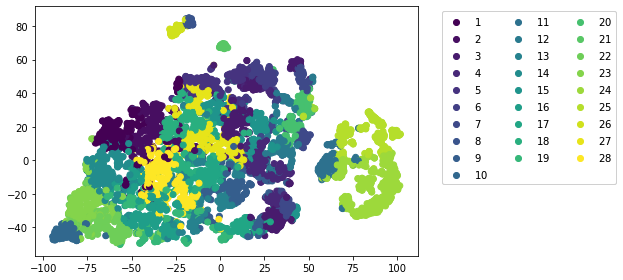

In [12]:
#차원축소 및 결과 그래프 출력
tsne = TSNE(verbose=2,random_state=42).fit_transform(features)
fig, ax = plt.subplots()
scatter=ax.scatter(tsne[:,0],tsne[:,1],c=Labels)
legend1 = ax.legend(*scatter.legend_elements(num=None), bbox_to_anchor=(1.05, 1.0), ncol=3, loc='upper left', fontsize=10)
ax.add_artist(legend1)
plt.tight_layout()
#plt.savefig('affinity_propagation_grahp3.png')

In [13]:
#Label별 기술통계량 추출
df.groupby('ap_pred').describe().to_excel('./affinity__그룹별 기술통계량3.xlsx')